# SVC (Support Vector Classifier) sobre el dataset Iris

En este notebook aplicamos `SVC` de scikit-learn sobre el dataset toy **Iris**.

Vamos a:
1. Cargar y preparar los datos (usamos solo 2 features para poder graficar la frontera de decisión).
2. Buscar los mejores hiperparámetros con **Grid Search**.
3. Buscar los mejores hiperparámetros con **Random Search**.
4. Entrenar el modelo final y visualizar la frontera de decisión y la matriz de confusión.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## 1. Datos

Usamos únicamente 2 de las 4 features de Iris (largo y ancho de pétalo) para poder graficar la frontera de decisión del clasificador en 2D.

In [ ]:
iris = load_iris()
X = iris.data[:, [2, 3]]  # petal length, petal width
y = iris.target
feature_names = [iris.feature_names[2], iris.feature_names[3]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)  # solo transform, el scaler ya se ajustó con el train

## 2. Grid Search

**Grid Search** prueba de forma exhaustiva **todas** las combinaciones posibles dentro de una grilla (rejilla) de hiperparámetros que definimos manualmente. Con `cv=5` hace validación cruzada de 5 folds para cada combinación.

- Ventaja: garantiza encontrar la mejor combinación *dentro de la grilla* que definimos.
- Desventaja: el número de combinaciones crece rápido (crecimiento exponencial con el número de hiperparámetros), por lo que puede ser muy costoso computacionalmente.

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Mejores parámetros (Grid Search):', grid_search.best_params_)
print('Mejor accuracy (CV):', grid_search.best_score_)

Mejores parámetros (Grid Search): {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Mejor accuracy (CV): 0.980952380952381


## 3. Random Search

**Random Search** no prueba todas las combinaciones, sino que muestrea al azar `n_iter` combinaciones de hiperparámetros (pueden venir de distribuciones continuas, no solo de una lista fija).

- Ventaja: mucho más eficiente cuando hay muchos hiperparámetros o rangos amplios, porque no crece exponencialmente; en la práctica suele encontrar soluciones casi tan buenas como Grid Search con mucho menos cómputo.
- Desventaja: al ser aleatorio, no garantiza encontrar la combinación óptima.

In [ ]:
from scipy.stats import uniform, loguniform

param_dist = {
    'C': loguniform(1e-2, 1e2),
    'gamma': loguniform(1e-3, 1e1),
    'kernel': ['rbf', 'linear']
}

random_search = RandomizedSearchCV(
    SVC(), param_distributions=param_dist, n_iter=20,
    cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)
random_search.fit(X_train, y_train)

print('Mejores parámetros (Random Search):', random_search.best_params_)
print('Mejor accuracy (CV):', random_search.best_score_)

Mejores parámetros (Random Search): {'C': np.float64(0.31489116479568624), 'gamma': np.float64(6.351221010640703), 'kernel': 'rbf'}
Mejor accuracy (CV): 0.980952380952381


## 4. Modelo final

Nos quedamos con el mejor estimador entre los dos métodos de búsqueda (según el accuracy de validación cruzada) y lo evaluamos sobre el conjunto de test.

In [ ]:
if grid_search.best_score_ >= random_search.best_score_:
    best_model = grid_search.best_estimator_
    print('Se usa el mejor modelo de Grid Search:', grid_search.best_params_)
else:
    best_model = random_search.best_estimator_
    print('Se usa el mejor modelo de Random Search:', random_search.best_params_)

y_pred = best_model.predict(X_test)
print('Accuracy en test:', accuracy_score(y_test, y_pred))

Se usa el mejor modelo de Grid Search: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Accuracy en test: 0.9111111111111111


## 5. Frontera de decisión

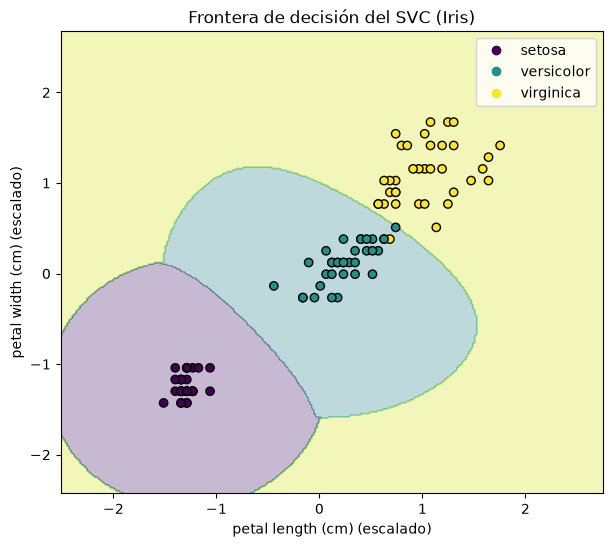

In [ ]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.viridis)
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.viridis, edgecolors='k')
plt.xlabel(feature_names[0] + ' (escalado)')
plt.ylabel(feature_names[1] + ' (escalado)')
plt.title('Frontera de decisión del SVC (Iris)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

## 6. Matriz de confusión

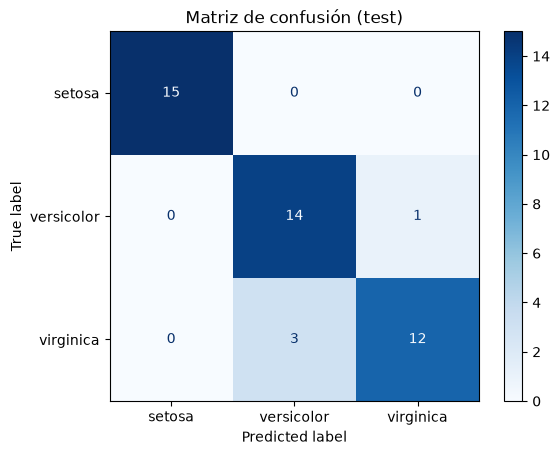

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión (test)')
plt.show()